In [58]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('activemq-5.0.0.csv')

df.head()

,File,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,...,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE,HeuBug,HeuBugCount,RealBug,RealBugCount
0,activemq-console/src/main/java/org/apache/acti...,0,10,171,5,0,2,0,18,2,...,1.00000,1.0,0,1,1,0,False,0,False,0
1,activemq-console/src/main/java/org/apache/acti...,0,8,123,5,0,1,1,15,3,...,0.98374,0.5,0,1,2,1,False,0,False,0
2,activemq-console/src/main/java/org/apache/acti...,0,7,136,5,0,1,1,16,2,...,1.00000,1.0,0,1,1,0,False,0,False,0
3,activemq-console/src/main/java/org/apache/acti...,0,29,241,17,0,4,5,29,9,...,1.00000,1.0,0,1,1,0,False,0,False,0
4,activemq-console/src/main/java/org/apache/acti...,0,24,212,17,0,3,5,26,8,...,1.00000,1.0,0,1,1,0,False,0,False,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   File                       1884 non-null   object 
 1   CountDeclMethodPrivate     1884 non-null   int64  
 2   AvgLineCode                1884 non-null   int64  
 3   CountLine                  1884 non-null   int64  
 4   MaxCyclomatic              1884 non-null   int64  
 5   CountDeclMethodDefault     1884 non-null   int64  
 6   AvgEssential               1884 non-null   int64  
 7   CountDeclClassVariable     1884 non-null   int64  
 8   SumCyclomaticStrict        1884 non-null   int64  
 9   AvgCyclomatic              1884 non-null   int64  
 10  AvgLine                    1884 non-null   int64  
 11  CountDeclClassMethod       1884 non-null   int64  
 12  AvgLineComment             1884 non-null   int64  
 13  AvgCyclomaticModified      1884 non-null   int64

In [60]:
df = df.drop(columns=['HeuBug', 'HeuBugCount', 'RealBugCount'])

In [61]:
df.shape

(1884, 67)

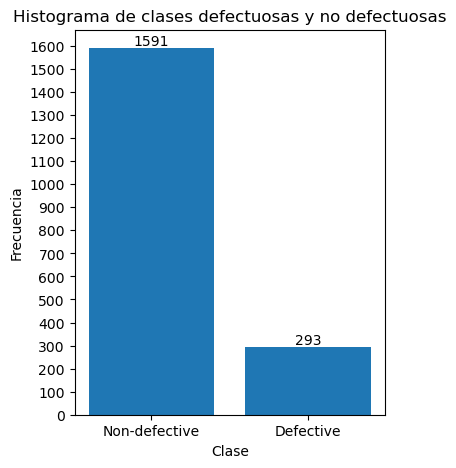

In [85]:
#Defective and Non-defective Class histogram

# Count the occurrences of each class
class_counts = df['RealBug'].value_counts()

# Plot the histogram with increased height
plt.figure(figsize=(4, 5))
bars = plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Histograma de clases defectuosas y no defectuosas')
plt.xticks([0, 1], ['Non-defective', 'Defective'])

# show more numbers in frequency (y axis)
plt.gca().set_yticks(range(0, class_counts.max() + 50, 100))

# Add value labels on top of bars
plt.bar_label(bars, labels=[f'{val}' for val in class_counts.values])

# show the grid
# plt.grid(axis='y')
plt.show()


In [63]:
class_counts

RealBug
False    1591
True      293
Name: count, dtype: int64

<Axes: xlabel='RealBug', ylabel='CountLineCode'>

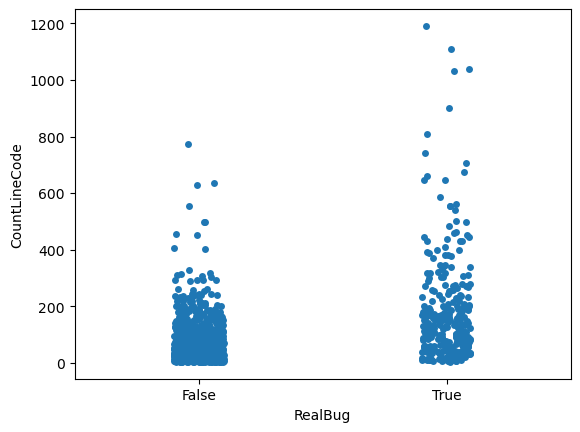

In [64]:
# Dispersion plot of class Defective
import seaborn as sns

sns.stripplot(x='RealBug', y='CountLineCode', data=df, jitter=True)

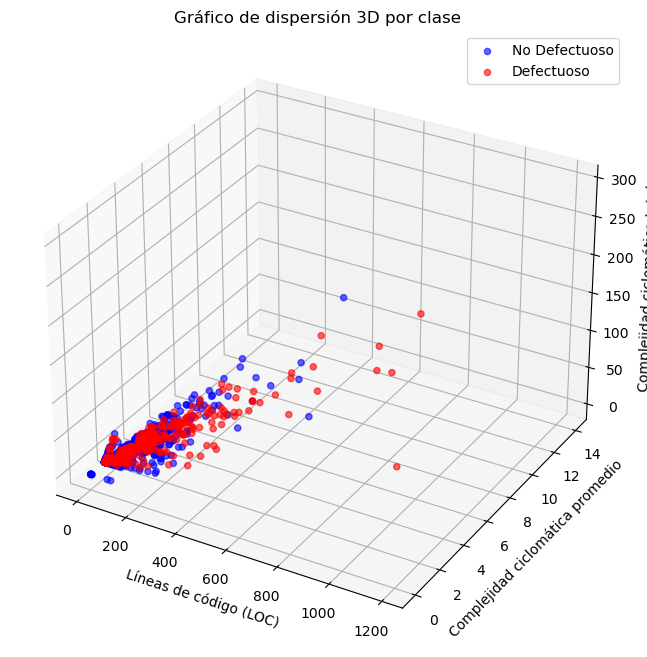

In [76]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# Separar por clase
defective = df[df['RealBug'] == 1]
non_defective = df[df['RealBug'] == 0]

# Graficar cada clase con diferente color
ax.scatter(non_defective['CountLineCode'], 
           non_defective['AvgCyclomatic'], 
           non_defective['SumCyclomatic'],
           c='blue', label='No Defectuoso', alpha=0.6)

ax.scatter(defective['CountLineCode'], 
           defective['AvgCyclomatic'], 
           defective['SumCyclomatic'],
           c='red', label='Defectuoso', alpha=0.6)

ax.set_xlabel('Líneas de código (LOC)')
ax.set_ylabel('Complejidad ciclomática promedio')
ax.set_zlabel('Complejidad ciclomática total')
ax.set_title('Gráfico de dispersión 3D por clase')
ax.legend()

plt.show()

## Preprocesamiento

- isNull / Missing values
- Duplicados
- Outlaiers ( no porque el metodo HCBOU de balanceo no lo recomienda)
- Transformación de los datos - Normalización/Estandarización (StandarScaler)
- Balanceo de clases - HCBOU
- Seleccion de caracteristicas (arbol de decision - CABOOST) 
- Reduccion de Dimensionalidad (PCA)
- Particion Train/Test

### Missing Values

In [84]:
df.isnull().sum()

File                      0
CountDeclMethodPrivate    0
AvgLineCode               0
CountLine                 0
MaxCyclomatic             0
                         ..
MINOR_COMMIT              0
MINOR_LINE                0
MAJOR_COMMIT              0
MAJOR_LINE                0
RealBug                   0
Length: 67, dtype: int64

### Duplicated

In [67]:
df.duplicated().sum()

0

### Normalización

In [68]:
from sklearn.preprocessing import StandardScaler

df_numeric = df.select_dtypes(include=['float64', 'int64'])
scaler = StandardScaler()
df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

In [69]:
df_numeric.describe()

,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,AvgLine,...,ADEV,DDEV,Added_lines,Del_lines,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE
count,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,...,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.00000,1884.000000,1884.000000
mean,0.245223,6.675690,131.980361,2.932590,0.682059,1.063694,0.664013,15.209130,1.493100,9.168790,...,2.822718,1.220807,44.551486,38.695329,0.751368,0.930954,0.000531,2.02017,1.220276,0.321656
std,0.994063,5.957579,149.558899,3.387086,3.216275,0.322922,1.565751,23.907522,0.947061,7.842188,...,1.950909,0.449313,89.982922,80.045258,0.195773,0.144749,0.023039,0.80599,0.447798,0.588018
min,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.333333,0.333333,0.000000,1.00000,1.000000,0.000000
25%,0.000000,3.000000,51.750000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000,5.000000,...,2.000000,1.000000,4.000000,4.000000,0.567568,1.000000,0.000000,1.00000,1.000000,0.000000
50%,0.000000,5.000000,94.000000,2.000000,0.000000,1.000000,0.000000,7.000000,1.000000,7.000000,...,2.000000,1.000000,16.000000,15.000000,0.750000,1.000000,0.000000,2.00000,1.000000,0.000000
75%,0.000000,8.000000,149.250000,4.000000,0.000000,1.000000,1.000000,17.000000,2.000000,11.000000,...,3.000000,1.000000,46.000000,37.000000,0.968750,1.000000,0.000000,3.00000,1.000000,1.000000
max,21.000000,63.000000,2075.000000,56.000000,44.000000,4.000000,23.000000,301.000000,14.000000,75.000000,...,23.000000,4.000000,1402.000000,1326.000000,1.000000,1.000000,1.000000,5.00000,4.000000,4.000000


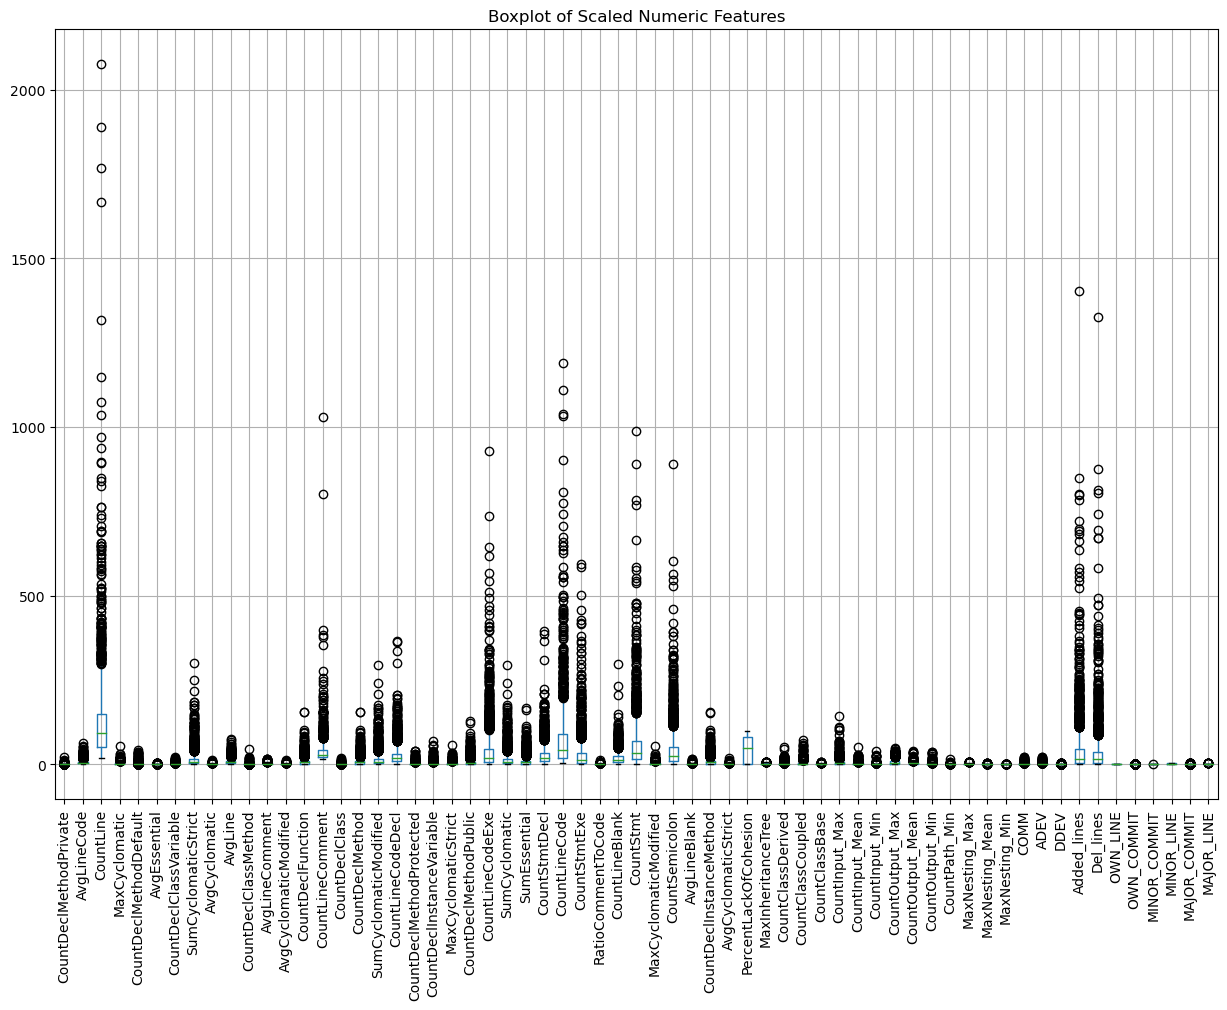

In [72]:
plt.figure(figsize=(15, 10))
df_numeric.drop(columns=['CountPath_Max', 'CountPath_Mean']).boxplot()
plt.title('Boxplot of Scaled Numeric Features')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_numeric_scaled.describe()

,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,AvgLine,...,ADEV,DDEV,Added_lines,Del_lines,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE
count,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,...,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03,1.884000e+03
mean,3.394312e-17,4.525750e-17,3.017167e-17,-3.771458e-17,1.508583e-17,6.222906e-17,1.508583e-17,-3.017167e-17,-8.297208e-17,1.131437e-16,...,3.017167e-17,7.542917e-17,-1.508583e-17,-1.508583e-17,4.525750e-17,-3.922317e-16,-3.771458e-18,-1.357725e-16,-4.525750e-17,7.542917e-18
std,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,...,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00,1.000265e+00
min,-2.467531e-01,-1.120835e+00,-7.489363e-01,-8.660450e-01,-2.121213e-01,-3.294841e+00,-4.241983e-01,-6.363339e-01,-1.576979e+00,-1.169473e+00,...,-9.345393e-01,-4.915623e-01,-4.841257e-01,-4.835465e-01,-2.135872e+00,-4.129764e+00,-2.304490e-02,-1.266072e+00,-4.920396e-01,-5.471623e-01
25%,-2.467531e-01,-6.171409e-01,-5.365890e-01,-5.707275e-01,-2.121213e-01,-1.972958e-01,-4.241983e-01,-5.108171e-01,-5.208012e-01,-5.317262e-01,...,-4.218218e-01,-4.915623e-01,-4.507772e-01,-4.335615e-01,-9.390933e-01,4.771290e-01,-2.304490e-02,-1.266072e+00,-4.920396e-01,-5.471623e-01
50%,-2.467531e-01,-2.813450e-01,-2.540166e-01,-2.754101e-01,-2.121213e-01,-1.972958e-01,-4.241983e-01,-3.434613e-01,-5.208012e-01,-2.766276e-01,...,-4.218218e-01,-4.915623e-01,-3.173832e-01,-2.961027e-01,-6.987009e-03,4.771290e-01,-2.304490e-02,-2.503159e-02,-4.920396e-01,-5.471623e-01
75%,-2.467531e-01,2.223490e-01,1.155011e-01,3.152247e-01,-2.121213e-01,-1.972958e-01,2.146423e-01,7.492813e-02,5.353769e-01,2.335696e-01,...,9.089579e-02,-4.915623e-01,1.610193e-02,-2.118525e-02,1.110677e+00,4.771290e-01,-2.304490e-02,1.216008e+00,-4.920396e-01,1.153917e+00
max,2.088428e+01,9.456738e+00,1.299512e+01,1.567173e+01,1.347193e+01,9.095339e+00,1.426913e+01,1.195719e+01,1.320951e+01,8.396724e+00,...,1.034525e+01,6.187068e+00,1.508963e+01,1.608648e+01,1.270344e+00,4.771290e-01,4.339355e+01,3.698088e+00,6.209184e+00,6.257153e+00


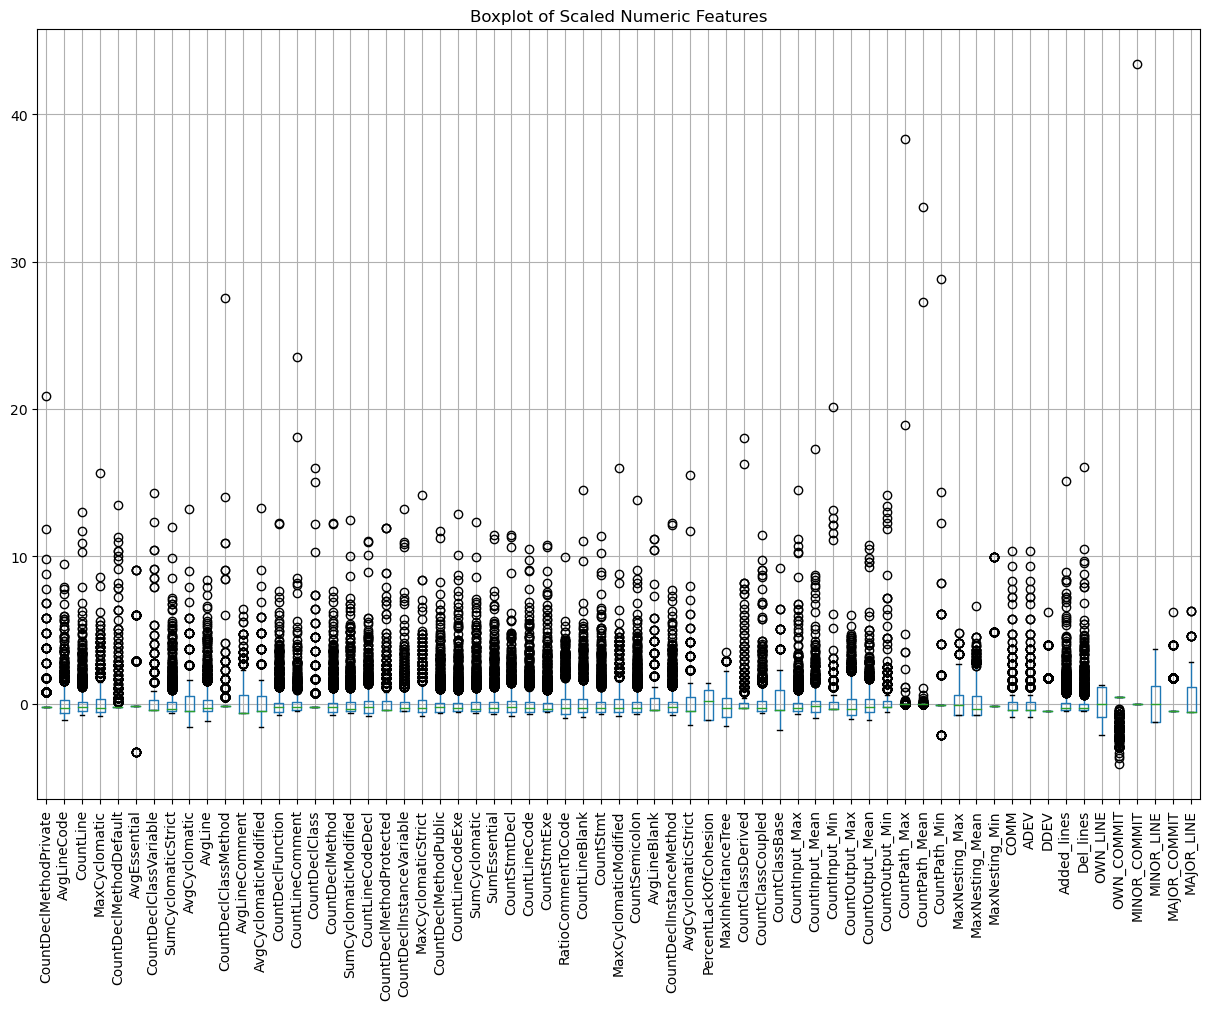

In [ ]:
plt.figure(figsize=(15, 10))
df_numeric_scaled.boxplot()
plt.title('Boxplot of Scaled Numeric Features')
plt.xticks(rotation=90)
plt.show()